CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [2]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 48.2MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.86MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [15]:
# TODO
#모델 초기화
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = myCNN().to(device)

# 손실 함수
criterion = nn.CrossEntropyLoss()

# 최적화 알고리즘 - Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 학습률 0.001


모델 학습 ✅

In [16]:
# TODO

train_losses = []
test_losses = []
test_accuracies = []

def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = output.max(1)
        correct += predicted.eq(target).sum().item()
        total += target.size(0)

        if batch_idx % 100 == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] "
                  f"Loss: {loss.item():.6f}")

    avg_loss = running_loss / len(train_loader)
    accuracy = 100. * correct / total
    train_losses.append(avg_loss)
    print(f"Epoch {epoch} - Average Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")


모델 평가 ✅

In [17]:
# TODO
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            correct += predicted.eq(target).sum().item()

    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    test_losses.append(avg_loss)
    test_accuracies.append(accuracy)
    print(f"\nTest Set - Average Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%\n")


10회 반복 시행 ✅

In [18]:
# TODO
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train(model, device, train_loader, optimizer, criterion, epoch)
    test(model, device, test_loader)

Train Epoch: 1 [0/60000] Loss: 2.298227
Train Epoch: 1 [6400/60000] Loss: 0.274008
Train Epoch: 1 [12800/60000] Loss: 0.070341
Train Epoch: 1 [19200/60000] Loss: 0.006475
Train Epoch: 1 [25600/60000] Loss: 0.019220
Train Epoch: 1 [32000/60000] Loss: 0.041268
Train Epoch: 1 [38400/60000] Loss: 0.045968
Train Epoch: 1 [44800/60000] Loss: 0.086804
Train Epoch: 1 [51200/60000] Loss: 0.037049
Train Epoch: 1 [57600/60000] Loss: 0.117532
Epoch 1 - Average Loss: 0.1372, Accuracy: 95.78%

Test Set - Average Loss: 0.0382, Accuracy: 98.66%

Train Epoch: 2 [0/60000] Loss: 0.013246
Train Epoch: 2 [6400/60000] Loss: 0.024713
Train Epoch: 2 [12800/60000] Loss: 0.179728
Train Epoch: 2 [19200/60000] Loss: 0.005455
Train Epoch: 2 [25600/60000] Loss: 0.043401
Train Epoch: 2 [32000/60000] Loss: 0.083071
Train Epoch: 2 [38400/60000] Loss: 0.011532
Train Epoch: 2 [44800/60000] Loss: 0.001751
Train Epoch: 2 [51200/60000] Loss: 0.014068
Train Epoch: 2 [57600/60000] Loss: 0.063197
Epoch 2 - Average Loss: 0.038

결과 시각화

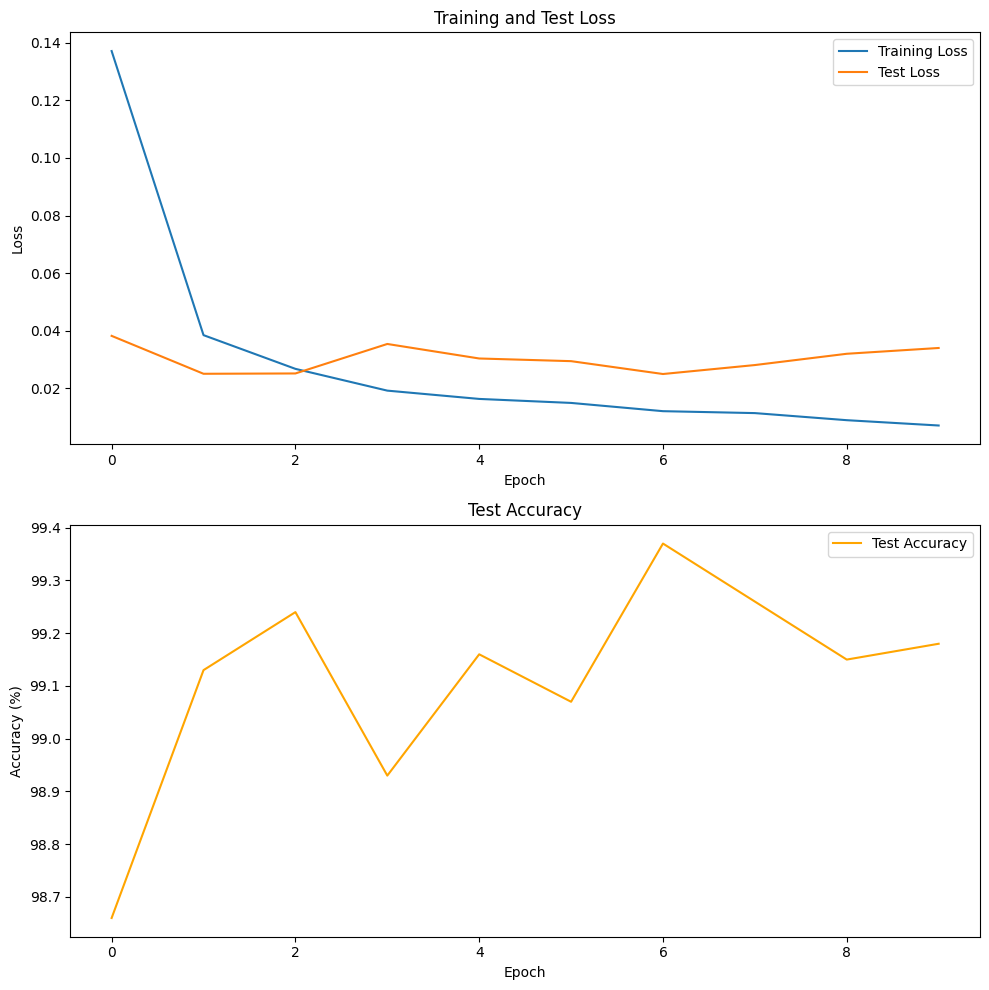

In [19]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()